In [2]:
%pip install transformers torch scikit-learn pillow tqdm pandas numpy matplotlib kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import pandas as pd
import numpy as np
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from tqdm.notebook import tqdm
import warnings
import re
warnings.filterwarnings("ignore")

In [4]:
import kagglehub
import os

# Download the latest version
path = kagglehub.dataset_download("hsankesara/flickr-image-dataset")

# Scan the directory to find the exact path of results.csv
csv_path = ""
for root, dirs, files in os.walk(path):
    if "results.csv" in files:
        csv_path = os.path.join(root, "results.csv")
        break

if csv_path:
    print(f"File found at: {csv_path}")
else:
    print("File results.csv not found. Please check the extraction process.")
IMAGES_DIR = os.path.join(path, "flickr30k_images")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

# TARGET_CLASSES = ["person", "dog", "car", "bus", "bike"]

# CATEGORIES = {
#     "People": ["man", "woman", "children", "person", "crowd", "people"],
#     "Animals": ["dog", "cat", "horse", "bird", "animal"],
#     "Urban": [
#         "street", "road", "avenue", "highway", "intersection",
#         "sidewalk", "crosswalk", "traffic", "traffic light",
#         "streetlight", "bridge", "overpass", "tunnel",
#         "city", "downtown", "urban", "building", "skyscraper",
#         "apartment", "office", "tower", "block", "storefront",
#         "shop", "mall",
#         "bus", "taxi", "car", "truck", "motorcycle",
#         "bicycle", "subway", "metro", "train", "tram",
#         "plaza", "square", "station", "bus stop",
#         "parking", "parking lot",
#         "crowd", "pedestrian", "commuter",
#         "billboard", "sign", "neon"
#     ],
#     "Nature": [
#         "tree","trees","forest","woods","jungle",
#         "mountain","mountains","hill","hills",
#         "river","lake","water","stream","waterfall",
#         "ocean","sea","beach","shore","coast",
#         "grass","field","meadow","valley",
#         "sky","cloud","sunset","sunrise",
#         "snow","ice","rock","cliff","sand",
#         "desert","island","trail","path"
#     ],
#     "Sports/Activities": [
#         "football", "basketball", "running", "bicycle", "swimming",
#         "jumping", "playing", "dancing", "climbing", "skating", "walking",
#         "hiking", "soccer", "tennis", "guitar", "music"
#     ]
# }

# Tự động lấy danh sách class từ dictionary
# TARGET_CLASSES = list(CATEGORIES.keys())

TARGET_CLASSES = ["people", "animals", "urban", "nature", "sports"]

from transformers import pipeline
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0)

File found at: /root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/results.csv
cuda


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [5]:
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)
print("Đã tải xong mô hình CLIP")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Đã tải xong mô hình CLIP


In [6]:
print("Đang đọc và xử lý dữ liệu...")

df_captions = pd.read_csv(csv_path, sep='|')

# QUAN TRỌNG: Loại bỏ khoảng trắng thừa ở tên cột
df_captions.columns = df_captions.columns.str.strip()

df_captions.rename(columns={'image_name': 'image'}, inplace=True)

if 'comment' not in df_captions.columns:
    # Tìm cột chứa chữ 'comment' gần nhất
    comment_col = [c for c in df_captions.columns if 'comment' in c.lower()]
    if comment_col:
        df_captions.rename(columns={comment_col[0]: 'comment'}, inplace=True)

# Gom nhóm captions
grouped = df_captions.groupby('image')['comment'].apply(list).reset_index()
grouped.columns = ['image', 'captions']

print(f"Các cột sau khi làm sạch: {df_captions.columns.tolist()}")

Đang đọc và xử lý dữ liệu...
Các cột sau khi làm sạch: ['image', 'comment_number', 'comment']


In [7]:
# Lọc ảnh tồn tại
valid_rows = []
for idx, row in grouped.iterrows():
    img_path = os.path.join("/root/.cache/kagglehub/datasets/hsankesara/flickr-image-dataset/versions/1/flickr30k_images/flickr30k_images", row['image'])
    if os.path.exists(img_path):
        valid_rows.append({
            'path': img_path,
            'captions': row['captions'],
            'image_name': row['image']
        })

df_valid = pd.DataFrame(valid_rows)
print(f"Tổng số ảnh hợp lệ: {len(df_valid)}")

Tổng số ảnh hợp lệ: 31783


In [8]:
from transformers.pipelines.pt_utils import KeyDataset
from tqdm.auto import tqdm

# 1. Định nghĩa Generator để stream dữ liệu
def data_generator():
    for c in df_valid['captions']:
        # Lấy caption đầu tiên làm đại diện
        yield c[0] if isinstance(c, list) and len(c) > 0 else ""

print("Đang gán nhãn bằng Zero-Shot Classification (BART)...")

# Gọi pipeline trực tiếp với generator
results_iter = classifier(
    data_generator(), 
    candidate_labels=TARGET_CLASSES, 
    batch_size=100,     
    truncation=True
)

# 3. Thu thập kết quả
predicted_labels = []
for res in tqdm(results_iter, total=len(df_valid), desc="Đang phân loại Zero-shot"):
    predicted_labels.append(res['labels'][0])

df_valid['label'] = predicted_labels
df_clean = df_valid.dropna(subset=['label']).reset_index(drop=True)

print(f"Số lượng ảnh sau khi gán nhãn: {len(df_clean)}")
print(df_clean['label'].value_counts())

Đang gán nhãn bằng Zero-Shot Classification (BART)...


  0%|          | 0/31783 [00:00<?, ?it/s]

Số lượng ảnh sau khi gán nhãn: 31783
label
people     18506
sports      5155
animals     3330
urban       3003
nature      1789
Name: count, dtype: int64


In [9]:
print("\n--- Bắt đầu Zero-Shot Classification ---")

templates = [
    "a photo of a {}",
    "a picture of a {}",
    "an image of a {}",
    "{}",
    "a blurry photo of a {}"
]

zero_shot_preds = []
true_labels = []


with torch.no_grad():
    eps = 1e-8
    
    for idx, row in tqdm(df_clean.iterrows(), total=len(df_clean), desc="Zero-Shot"):
        img_path = row['path']
        true_label = row['label']
        true_labels.append(true_label)
        
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            continue

        texts = []
        for cls in TARGET_CLASSES:
            for tmpl in templates:
                texts.append(tmpl.format(cls))
        
        inputs = processor(text=texts, images=image, return_tensors="pt", padding=True).to(device)
        
        outputs = model(**inputs)
        
        # Trích xuất trực tiếp từ trường image_embeds và text_embeds
        image_features = outputs.image_embeds
        text_features = outputs.text_embeds
        
        # if idx == 0: print(f"Type: {type(image_features)}")

        
        image_features = image_features / (image_features.norm(dim=-1, keepdim=True) + eps)
        text_features = text_features / (text_features.norm(dim=-1, keepdim=True) + eps)
        
        # Tính similarity
        logits_per_image = image_features @ text_features.T
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
        
        # Gộp điểm
        class_scores = []
        num_templates = len(templates)
        for i, cls in enumerate(TARGET_CLASSES):
            start = i * num_templates
            end = start + num_templates
            avg_score = np.mean(probs[start:end])
            class_scores.append(avg_score)
        
        pred_class = TARGET_CLASSES[np.argmax(class_scores)]
        zero_shot_preds.append(pred_class)

zs_accuracy = accuracy_score(true_labels, zero_shot_preds)
print(f"\nZero-Shot Accuracy: {zs_accuracy:.4f}")
print(classification_report(true_labels, zero_shot_preds, target_names=TARGET_CLASSES))


--- Bắt đầu Zero-Shot Classification ---


Zero-Shot:   0%|          | 0/31783 [00:00<?, ?it/s]


Zero-Shot Accuracy: 0.6327
              precision    recall  f1-score   support

      people       0.75      0.49      0.60      3330
     animals       0.45      0.29      0.35      1789
       urban       0.81      0.67      0.73     18506
      nature       0.50      0.82      0.62      5155
      sports       0.29      0.46      0.36      3003

    accuracy                           0.63     31783
   macro avg       0.56      0.55      0.53     31783
weighted avg       0.68      0.63      0.64     31783



In [41]:
print("\n--- Bắt đầu Few-Shot Classification ---")

# 64-shots classification, có thể sửa
shots_per_class = 128
train_data = []
test_data = []
eps = 1e-8 

for cls in TARGET_CLASSES:
    cls_df = df_clean[df_clean['label'] == cls]
    # Giảm điều kiện xuống còn 5 mẫu để tránh bỏ qua lớp nếu dữ liệu ít
    if len(cls_df) < shots_per_class + 5: 
        print(f"Bỏ qua lớp {cls} do thiếu dữ liệu (có {len(cls_df)} mẫu).")
        continue
    
    cls_df_shuffled = cls_df.sample(frac=1, random_state=42).reset_index(drop=True)
    train_chunk = cls_df_shuffled.iloc[:shots_per_class]
    test_chunk = cls_df_shuffled.iloc[shots_per_class:]
    
    train_data.append(train_chunk)
    test_data.append(test_chunk)

if len(train_data) == 0:
    print("Không đủ dữ liệu để chạy Few-Shot (cần ít nhất 2 lớp có đủ mẫu).")
    print("Dừng chương trình tại đây.")
else:
    df_train = pd.concat(train_data, ignore_index=True)
    df_test = pd.concat(test_data, ignore_index=True)

    print(f"Train size: {len(df_train)}, Test size: {len(df_test)}")

def extract_embeddings(df_subset):
    embeddings = []
    labels = []
    success_count = 0
    
    BATCH_SIZE = 32 
    total_rows = len(df_subset)
    
    # Tính tổng số batch cần chạy
    total_batches = (total_rows + BATCH_SIZE - 1) // BATCH_SIZE
    
    with tqdm(total=total_batches, desc="Extracting Embeddings", unit="batch") as pbar:
        for i in range(0, total_rows, BATCH_SIZE):
            batch_df = df_subset.iloc[i:i+BATCH_SIZE]
            batch_labels = batch_df['label'].tolist()
            batch_paths = batch_df['path'].tolist()
            images_batch = []
            valid_indices = []
            
            # Chuẩn bị ảnh cho batch (vẫn giữ logic mở ảnh riêng để tránh lỗi làm crash cả batch)
            for idx, img_path in enumerate(batch_paths):
                try:
                    img = Image.open(img_path).convert("RGB")
                    images_batch.append(img)
                    valid_indices.append(idx)
                except Exception:
                    continue
            if not images_batch:
                pbar.update(1)
                continue
            try:
                inputs = processor(images=images_batch, return_tensors="pt", padding=True).to(device)
                
                with torch.no_grad():
                    vision_outputs = model.vision_model(pixel_values=inputs['pixel_values'])
                    pooler_output = vision_outputs.pooler_output
                    image_embeds = model.visual_projection(pooler_output)
                    
                    norms = image_embeds.norm(dim=-1, keepdim=True)
                    image_embeds = image_embeds / (norms + eps)
                
                embeddings.append(image_embeds.cpu().numpy())
                current_batch_labels = [batch_labels[idx] for idx in valid_indices]
                labels.extend(current_batch_labels)
                success_count += len(images_batch)
                
            except Exception as e:
                pbar.write(f"Lỗi batch {i//BATCH_SIZE}: {e}")
            
            pbar.update(1)

    if len(embeddings) == 0:
        raise ValueError(f"Không trích xuất được embedding nào từ {len(df_subset)} ảnh.")
    
    print(f"\nHoàn tất! Đã trích xuất thành công {success_count}/{total_rows} ảnh.")
    return np.vstack(embeddings), labels


--- Bắt đầu Few-Shot Classification ---
Train size: 640, Test size: 31143


In [42]:
print("Trích xuất Train Embeddings...")
X_train, y_train = extract_embeddings(df_train)
y_train_idx = [TARGET_CLASSES.index(l) for l in y_train]

print("Trích xuất Test Embeddings...")
X_test, y_test = extract_embeddings(df_test)
y_test_idx = [TARGET_CLASSES.index(l) for l in y_test]

Trích xuất Train Embeddings...


Extracting Embeddings:   0%|          | 0/20 [00:00<?, ?batch/s]


Hoàn tất! Đã trích xuất thành công 640/640 ảnh.
Trích xuất Test Embeddings...


Extracting Embeddings:   0%|          | 0/974 [00:00<?, ?batch/s]


Hoàn tất! Đã trích xuất thành công 31143/31143 ảnh.


In [43]:
try:
    clf = LogisticRegression(max_iter=100, solver='lbfgs', class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train_idx)

    y_pred_idx = clf.predict(X_test)
    y_pred = [TARGET_CLASSES[i] for i in y_pred_idx]
    y_test_true = [TARGET_CLASSES[i] for i in y_test_idx]

    fs_accuracy = accuracy_score(y_test_true, y_pred)
    print(f"\nFew-Shot ({shots_per_class} shots) Accuracy: {fs_accuracy:.4f}")
    print(classification_report(y_test_true, y_pred, target_names=TARGET_CLASSES))

except ValueError as ve:
    print(f"\nLỗi: {ve}")


Few-Shot (128 shots) Accuracy: 0.6210
              precision    recall  f1-score   support

      people       0.90      0.79      0.84      3202
     animals       0.30      0.74      0.43      1661
       urban       0.90      0.53      0.67     18378
      nature       0.71      0.74      0.72      5027
      sports       0.25      0.72      0.38      2875

    accuracy                           0.62     31143
   macro avg       0.61      0.70      0.61     31143
weighted avg       0.78      0.62      0.66     31143



In [44]:
zs_macro_f1 = f1_score(true_labels, zero_shot_preds, average='macro')
fs_macro_f1 = f1_score(y_test_true, y_pred, average='macro')
print(f"Zero-Shot Accuracy: {zs_accuracy:.4f} | Macro F1: {zs_macro_f1:.4f}")
print(f"Few-Shot Accuracy:  {fs_accuracy:.4f} | Macro F1: {fs_macro_f1:.4f}")

if fs_macro_f1 > zs_macro_f1:
    print("=> Few-shot learning đã cải thiện hiệu suất!")
else:
    print("=> Zero-shot vẫn hoạt động tốt hơn hoặc tương đương.")

Zero-Shot Accuracy: 0.6327 | Macro F1: 0.5311
Few-Shot Accuracy:  0.6210 | Macro F1: 0.6075
=> Few-shot learning đã cải thiện hiệu suất!


Các mẫu sai tiêu biểu để phân tích:


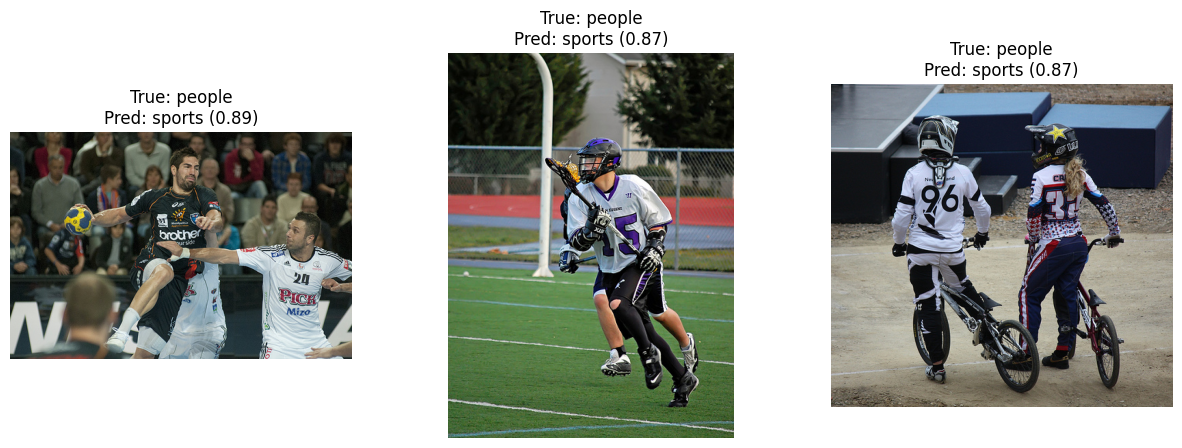

In [45]:
import matplotlib.pyplot as plt

# 1. Lấy xác suất và dự đoán
y_probs = clf.predict_proba(X_test)
y_preds_idx = np.argmax(y_probs, axis=1)

# 2. Tạo DataFrame kết quả để phân tích
analysis_df = df_test.copy()
analysis_df['pred_label'] = [TARGET_CLASSES[i] for i in y_preds_idx]
analysis_df['conf'] = np.max(y_probs, axis=1)

errors = analysis_df[analysis_df['label'] != analysis_df['pred_label']].sort_values(by='conf', ascending=False)

# 4. Hiển thị 3 mẫu lỗi tiêu biểu để đưa vào báo cáo
def plot_errors(error_df, num=3):
    plt.figure(figsize=(15, 5))
    for i in range(num):
        row = error_df.iloc[i]
        img = Image.open(row['path'])
        plt.subplot(1, num, i+1)
        plt.imshow(img)
        plt.title(f"True: {row['label']}\nPred: {row['pred_label']} ({row['conf']:.2f})")
        plt.axis('off')
    plt.show()

print("Các mẫu sai tiêu biểu để phân tích:")
plot_errors(errors)